# Regressão de Poisson — Sensibilidade dos Bairros à Chuva

**UFRJ Analytica — PS26 Hackathon**

Este notebook implementa uma **regressão de Poisson com foco interpretativo** para quantificar a sensibilidade de cada bairro do Rio à chuva, controlando por precipitação.

**Produto principal:** os coeficientes do modelo (`exp(coef)`) — não previsões pontuais.

Cada coeficiente de bairro indica o fator multiplicativo de eventos esperados naquele bairro comparado ao bairro de referência, **dado o mesmo volume de chuva**. Isso isola a vulnerabilidade estrutural do bairro do simples efeito de "chover mais".

**Período:** 2017–2024 | **Dados:** Alerta Rio + 1746

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

Path("../figuras").mkdir(exist_ok=True)
Path("../data/processed").mkdir(exist_ok=True, parents=True)

THRESHOLD_CHUVA = 5.0      # mm — mesmo do notebook 04
ANO_INICIO = 2017
ANO_FIM = 2024
ANO_SPLIT_TREINO_FIM = 2022  # treino: 2017-2022, teste: 2023-2024

In [3]:
CATEGORIA_ALAGAMENTO = "evento_alagamento"

# Eventos de alagamento
eventos = pd.read_parquet(
    "../data/processed/chamados_alagamento.parquet",
    columns=["data", "bairro", "categoria_chamado"]
)
eventos = eventos[eventos["categoria_chamado"] == CATEGORIA_ALAGAMENTO].copy()
eventos = eventos[eventos["bairro"].notna()].copy()

# Converter date32 para datetime64[ns]
eventos["data"] = pd.to_datetime(eventos["data"])
eventos["bairro"] = eventos["bairro"].str.strip().str.upper()

# Filtrar período
eventos = eventos[
    (eventos["data"].dt.year >= ANO_INICIO) &
    (eventos["data"].dt.year <= ANO_FIM)
].copy()

# Chuva do Alerta Rio
chuva = pd.read_parquet(
    "../data/processed/chuva_alertario.parquet",
    columns=["id_estacao", "data", "acumulado_chuva_24_h"]
)

# Garantir formato consistente (já vem como timestamp[ns], mas normalizar por garantia)
chuva["data"] = pd.to_datetime(chuva["data"]).dt.normalize()
chuva = chuva[
    (chuva["data"].dt.year >= ANO_INICIO) &
    (chuva["data"].dt.year <= ANO_FIM)
].copy()

# Validação
print(f"Eventos no período: {len(eventos)}")
print(f"Bairros únicos com eventos: {eventos['bairro'].nunique()}")
print(f"Registros de chuva: {len(chuva):,}")
print()
print("Verificação de tipos:")
print(f"  eventos['data'].dtype: {eventos['data'].dtype}")
print(f"  chuva['data'].dtype:   {chuva['data'].dtype}")
print()
print("Verificação de formato (deve ser meia-noite):")
print(f"  eventos['data'].iloc[0]: {eventos['data'].iloc[0]}")
print(f"  chuva['data'].iloc[0]:   {chuva['data'].iloc[0]}")

Eventos no período: 335
Bairros únicos com eventos: 87
Registros de chuva: 8,958,136

Verificação de tipos:
  eventos['data'].dtype: datetime64[ns]
  chuva['data'].dtype:   datetime64[ns]

Verificação de formato (deve ser meia-noite):
  eventos['data'].iloc[0]: 2017-08-24 00:00:00
  chuva['data'].iloc[0]:   2017-01-01 00:00:00


In [4]:
mapeamento_path = Path("../data/processed/bairro_estacao.parquet")

if mapeamento_path.exists():
    bairro_estacao = pd.read_parquet(mapeamento_path)
    print(f"Mapeamento carregado do cache: {len(bairro_estacao)} bairros")
else:
    print("Reconstruindo mapeamento a partir dos parquets locais...")

    # Chuva diária temporária para o matching
    chuva_diaria_temp = (
        chuva
        .groupby(["id_estacao", "data"])["acumulado_chuva_24_h"]
        .max()
        .reset_index()
        .rename(columns={"acumulado_chuva_24_h": "chuva_24h"})
    )
    chuva_diaria_temp = chuva_diaria_temp[chuva_diaria_temp["chuva_24h"] < 500]

    # IVH para tie-breaking pelo total_chuva_mm
    ivh = pd.read_parquet(
        "../data/processed/indice_vulnerabilidade_hidrica.parquet",
        columns=["bairro", "total_chuva_mm"]
    )

    mapping_rows = []
    for bairro_nome, grp in eventos.groupby("bairro"):
        event_dates = grp["data"].dt.normalize().unique()

        # Estações com chuva >= 5mm nos dias de evento deste bairro
        chuva_match = chuva_diaria_temp[
            chuva_diaria_temp["data"].isin(event_dates) &
            (chuva_diaria_temp["chuva_24h"] >= THRESHOLD_CHUVA)
        ]
        if chuva_match.empty:
            # Fallback: qualquer chuva no dia do evento
            chuva_match = chuva_diaria_temp[chuva_diaria_temp["data"].isin(event_dates)]
        if chuva_match.empty:
            continue

        # Votar: estação que aparece em mais dias de evento
        votos = chuva_match.groupby("id_estacao").size()

        # Tie-breaker: entre empatadas, preferir a que tem total_chuva mais próximo do IVH
        ivh_row = ivh[ivh["bairro"] == bairro_nome]
        if not ivh_row.empty:
            total_ivh = ivh_row["total_chuva_mm"].values[0]
            top_estacoes = votos[votos == votos.max()].index
            totais = (
                chuva_match[chuva_match["id_estacao"].isin(top_estacoes)]
                .groupby("id_estacao")["chuva_24h"]
                .sum()
            )
            best = (totais - total_ivh).abs().idxmin()
        else:
            best = votos.idxmax()

        mapping_rows.append({"bairro": bairro_nome, "id_estacao": str(best)})

    bairro_estacao = pd.DataFrame(mapping_rows)
    bairro_estacao.to_parquet(mapeamento_path, index=False)
    print(f"Mapeamento reconstruído e salvo: {len(bairro_estacao)} bairros")

print(bairro_estacao.head())

Mapeamento carregado do cache: 80 bairros
            bairro id_estacao
0         ANCHIETA         28
1          ANDARAÍ          1
2            BANGU          3
3  BARRA DA TIJUCA          1
4          BENFICA          1


In [5]:
chuva_diaria = (
    chuva
    .groupby(["id_estacao", "data"])["acumulado_chuva_24_h"]
    .max()
    .reset_index()
    .rename(columns={"acumulado_chuva_24_h": "chuva_24h"})
)

# Limpar valores impossíveis
chuva_diaria = chuva_diaria[chuva_diaria["chuva_24h"] < 500].copy()

print(f"Registros de chuva diária: {len(chuva_diaria):,}")
print(chuva_diaria["chuva_24h"].describe())

Registros de chuva diária: 87,402
count    87402.000000
mean         6.688710
std         16.544801
min          0.000000
25%          0.000000
50%          0.000000
75%          5.600000
max        482.400000
Name: chuva_24h, dtype: float64


In [6]:
# 1. Filtrar dias com chuva >= 5mm por estação
chuva_relevante = chuva_diaria[chuva_diaria["chuva_24h"] >= THRESHOLD_CHUVA].copy()
print(f"Dias-estação com chuva >= {THRESHOLD_CHUVA}mm: {len(chuva_relevante):,}")

# 2. Expandir pra cada bairro associado a cada estação
grade = chuva_relevante.merge(
    bairro_estacao[["bairro", "id_estacao"]],
    on="id_estacao",
    how="inner"
)
print(f"Linhas na grade (bairro × dia): {len(grade):,}")

# 3. Contar eventos por (bairro, dia)
contagem_eventos = (
    eventos
    .groupby(["bairro", "data"])
    .size()
    .reset_index(name="n_eventos")
)

# 4. Left join — preserva todas as linhas da grade, preenche 0 onde não houve evento
dataset = grade.merge(
    contagem_eventos,
    on=["bairro", "data"],
    how="left"
)
dataset["n_eventos"] = dataset["n_eventos"].fillna(0).astype(int)

# 5. Adicionar features temporais
dataset["mes"] = dataset["data"].dt.month
dataset["ano"] = dataset["data"].dt.year

# 6. Adicionar IVH normalizado do bairro 
ivh = pd.read_parquet("../data/processed/indice_vulnerabilidade_hidrica.parquet")
ivh = ivh[["bairro", "ivh_normalizado"]].copy()
ivh["bairro"] = ivh["bairro"].str.strip().str.upper()

dataset = dataset.merge(ivh, on="bairro", how="left")
# Bairros sem IVH (não tiveram eventos com chuva ≥5mm no histórico) recebem 0
# Interpretação: "baixa vulnerabilidade conhecida"
dataset["ivh_normalizado"] = dataset["ivh_normalizado"].fillna(0)

# 7. Como o target é binário (0/1), criar versão explícita pra Logit
dataset["evento_ocorreu"] = (dataset["n_eventos"] > 0).astype(int)

print(f"\nDataset final: {len(dataset):,} linhas")
print(f"Linhas com pelo menos 1 evento: {(dataset['evento_ocorreu'] == 1).sum()}")
print(f"Proporção de zeros: {(dataset['evento_ocorreu'] == 0).mean():.1%}")
print(f"\nDistribuição do IVH no dataset:")
print(dataset["ivh_normalizado"].describe())
print(f"\nBairros sem IVH no dataset: {(dataset['ivh_normalizado'] == 0).sum()} linhas")

Dias-estação com chuva >= 5.0mm: 23,126
Linhas na grade (bairro × dia): 56,767

Dataset final: 56,767 linhas
Linhas com pelo menos 1 evento: 124
Proporção de zeros: 99.8%

Distribuição do IVH no dataset:
count    56767.000000
mean        16.402732
std         25.016617
min          0.000000
25%          0.000000
50%          0.000000
75%         28.000000
max        100.000000
Name: ivh_normalizado, dtype: float64

Bairros sem IVH no dataset: 31158 linhas


In [7]:
n_total = len(dataset)
n_eventos = dataset["evento_ocorreu"].sum()
n_zeros = n_total - n_eventos
taxa_base = n_eventos / n_total

print(f"Total de observações:     {n_total:,}")
print(f"Com evento (target=1):    {n_eventos} ({taxa_base*100:.3f}%)")
print(f"Sem evento (target=0):    {n_zeros:,} ({(1-taxa_base)*100:.3f}%)")
print(f"Taxa base:                {taxa_base:.6f}")
print()
print("Verificação do target:")
print(f"  Valores únicos: {sorted(dataset['evento_ocorreu'].unique())}")
print(f"  Máximo:         {dataset['evento_ocorreu'].max()}")
print()
print("Interpretação:")
if taxa_base < 0.01:
    print("  Target desbalanceado (<1% de positivos) — dataset adequado para Logit")
    print("  Foco do modelo: interpretação dos coeficientes (odds ratio), não previsão pontual")
else:
    print("  Target relativamente balanceado — Logit adequada")

Total de observações:     56,767
Com evento (target=1):    124 (0.218%)
Sem evento (target=0):    56,643 (99.782%)
Taxa base:                0.002184

Verificação do target:
  Valores únicos: [np.int64(0), np.int64(1)]
  Máximo:         1

Interpretação:
  Target desbalanceado (<1% de positivos) — dataset adequado para Logit
  Foco do modelo: interpretação dos coeficientes (odds ratio), não previsão pontual


In [8]:
dataset.to_parquet("../data/processed/dataset_logit.parquet", index=False)
print(f"Dataset Logit salvo: {len(dataset):,} linhas")
print(f"Soma de evento_ocorreu: {dataset['evento_ocorreu'].sum()} eventos (esperado ≤ 335)")

Dataset Logit salvo: 56,767 linhas
Soma de evento_ocorreu: 124 eventos (esperado ≤ 335)


In [9]:
print("Distribuição completa do target:")
print(dataset["n_eventos"].value_counts().sort_index())
print()
print(f"Linhas com target = 0: {(dataset['n_eventos'] == 0).sum()}")
print(f"Linhas com target = 1: {(dataset['n_eventos'] == 1).sum()}")
print(f"Linhas com target >= 2: {(dataset['n_eventos'] >= 2).sum()}")
print(f"Maior valor de target: {dataset['n_eventos'].max()}")

Distribuição completa do target:
n_eventos
0    56643
1      124
Name: count, dtype: int64

Linhas com target = 0: 56643
Linhas com target = 1: 124
Linhas com target >= 2: 0
Maior valor de target: 1


In [10]:
treino = dataset[dataset["ano"] <= ANO_SPLIT_TREINO_FIM].copy()
teste  = dataset[dataset["ano"] >  ANO_SPLIT_TREINO_FIM].copy()

print(f"Treino (2017-{ANO_SPLIT_TREINO_FIM}): {len(treino):,} linhas, {treino['n_eventos'].sum()} eventos")
print(f"Teste  ({ANO_SPLIT_TREINO_FIM+1}-{ANO_FIM}):  {len(teste):,}  linhas, {teste['n_eventos'].sum()}  eventos")

# Alertar bairros com zero eventos no treino
bairros_sem_evento_treino = (
    treino.groupby("bairro")["n_eventos"].sum()
    .pipe(lambda s: s[s == 0].index.tolist())
)
if bairros_sem_evento_treino:
    print(f"\n⚠️  Bairros com ZERO eventos no treino ({len(bairros_sem_evento_treino)}): coeficientes instáveis possíveis")
    print(bairros_sem_evento_treino[:10])

Treino (2017-2022): 45,994 linhas, 100 eventos
Teste  (2023-2024):  10,773  linhas, 24  eventos

⚠️  Bairros com ZERO eventos no treino (29): coeficientes instáveis possíveis
['ANDARAÍ', 'BENFICA', 'BONSUCESSO', 'CACUIA', 'CAVALCANTI', 'COELHO NETO', 'COMPLEXO DO ALEMÃO', 'COPACABANA', 'DEL CASTILHO', 'GARDÊNIA AZUL']


In [11]:
def preparar_X_y(df):
    X = pd.DataFrame(index=df.index)
    X["ivh_normalizado"] = df["ivh_normalizado"].values
    
    meses_dummies = pd.get_dummies(df["mes"], prefix="mes", drop_first=True)
    X = pd.concat([X, meses_dummies], axis=1)
    
    X = sm.add_constant(X, has_constant="add")
    X = X.astype(float)
    
    y = df["evento_ocorreu"].values
    return X, y

X_treino, y_treino = preparar_X_y(treino)
X_teste, y_teste = preparar_X_y(teste)

colunas_comuns = X_treino.columns.intersection(X_teste.columns)
X_treino = X_treino[colunas_comuns]
X_teste = X_teste[colunas_comuns]

print(f"Features: {X_treino.shape[1]}")
print(f"Colunas: {list(X_treino.columns)}")

Features: 13
Colunas: ['const', 'ivh_normalizado', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']


In [12]:
modelo = sm.GLM(
    y_treino,
    X_treino,
    family=sm.families.Binomial()  # Logit
)

resultado = modelo.fit()

print(resultado.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45994
Model:                            GLM   Df Residuals:                    45981
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -695.22
Date:                Fri, 08 May 2026   Deviance:                       1390.4
Time:                        11:27:41   Pearson chi2:                 4.52e+04
No. Iterations:                    10   Pseudo R-squ. (CS):          0.0007727
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.3259      0.329    -

In [13]:
coefs = pd.DataFrame({
    "feature":   resultado.params.index,
    "coef":      resultado.params.values,
    "std_err":   resultado.bse.values,
    "z_value":   resultado.tvalues.values,
    "p_value":   resultado.pvalues.values,
    "ci_lower":  resultado.conf_int()[0].values,
    "ci_upper":  resultado.conf_int()[1].values,
})

coefs["odds_ratio"] = np.exp(coefs["coef"])
coefs["fator_mult_ci_lower"] = np.exp(coefs["ci_lower"])
coefs["fator_mult_ci_upper"] = np.exp(coefs["ci_upper"])
coefs["significativo"]       = coefs["p_value"] < 0.05

coefs["tipo"] = coefs["feature"].apply(
    lambda x: "mes" if x.startswith("mes_")
    else "chuva" if "chuva" in x
    else "ivh" if "ivh" in x
    else "intercepto"
)

coefs.to_csv("../data/processed/poisson_coeficientes.csv", index=False)
print("Tabela de coeficientes salva.")
print(coefs.head(20).to_string(index=False))

Tabela de coeficientes salva.
        feature      coef  std_err    z_value      p_value  ci_lower  ci_upper  odds_ratio  fator_mult_ci_lower  fator_mult_ci_upper  significativo       tipo
          const -6.325854 0.329118 -19.220639 2.486876e-82 -6.970913 -5.680795    0.001789             0.000939             0.003411           True intercepto
ivh_normalizado  0.012180 0.003240   3.759565 1.702089e-04  0.005830  0.018529    1.012254             1.005847             1.018702           True        ivh
          mes_2  0.749077 0.377066   1.986592 4.696763e-02  0.010041  1.488113    2.115047             1.010091             4.428733           True        mes
          mes_3 -0.098618 0.474952  -0.207638 8.355120e-01 -1.029507  0.832271    0.906089             0.357183             2.298533          False        mes
          mes_4 -0.865156 0.592120  -1.461117 1.439834e-01 -2.025689  0.295377    0.420986             0.131903             1.343633          False        mes
          mes_5 

In [14]:
# Verificação de estabilidade do modelo
instavel = (resultado.bse > 10).any()

if instavel:
    print("⚠️  Coeficientes instáveis detectados (std_err > 10)")
    print("   Sugestão: verificar separação perfeita ou reduzir features")
    print(resultado.bse[resultado.bse > 10])
else:
    print("✅ Modelo estável — todos os std_err dentro do esperado")
    print(f"   Maior std_err: {resultado.bse.max():.4f}")

✅ Modelo estável — todos os std_err dentro do esperado
   Maior std_err: 0.6588


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score

# Previsões (probabilidades)
y_pred_treino = resultado.predict(X_treino)
y_pred_teste = resultado.predict(X_teste)

# Métricas tradicionais
mae_teste = mean_absolute_error(y_teste, y_pred_teste)
rmse_teste = np.sqrt(mean_squared_error(y_teste, y_pred_teste))

# AUC-ROC: métrica natural pra classificação binária
auc_treino = roc_auc_score(y_treino, y_pred_treino)
auc_teste = roc_auc_score(y_teste, y_pred_teste)

# Baseline trivial: prever sempre a taxa base do treino
baseline_pred = np.full_like(y_teste, fill_value=y_treino.mean(), dtype=float)
mae_baseline = mean_absolute_error(y_teste, baseline_pred)

print(f"AUC-ROC treino: {auc_treino:.4f}")
print(f"AUC-ROC teste:  {auc_teste:.4f}")
print(f"  (0.5 = aleatório, 1.0 = perfeito; >0.7 já é razoável)")
print()
print(f"MAE teste: {mae_teste:.4f}")
print(f"MAE baseline (taxa base): {mae_baseline:.4f}")
print(f"Ganho: {(mae_baseline - mae_teste) / mae_baseline * 100:.1f}%")

AUC-ROC treino: 0.6835
AUC-ROC teste:  0.5979
  (0.5 = aleatório, 1.0 = perfeito; >0.7 já é razoável)

MAE teste: 0.0046
MAE baseline (taxa base): 0.0044
Ganho: -3.9%


Bairros robustos (≥3 eventos): 5
Bairros sob-amostrados (<3 eventos): 32


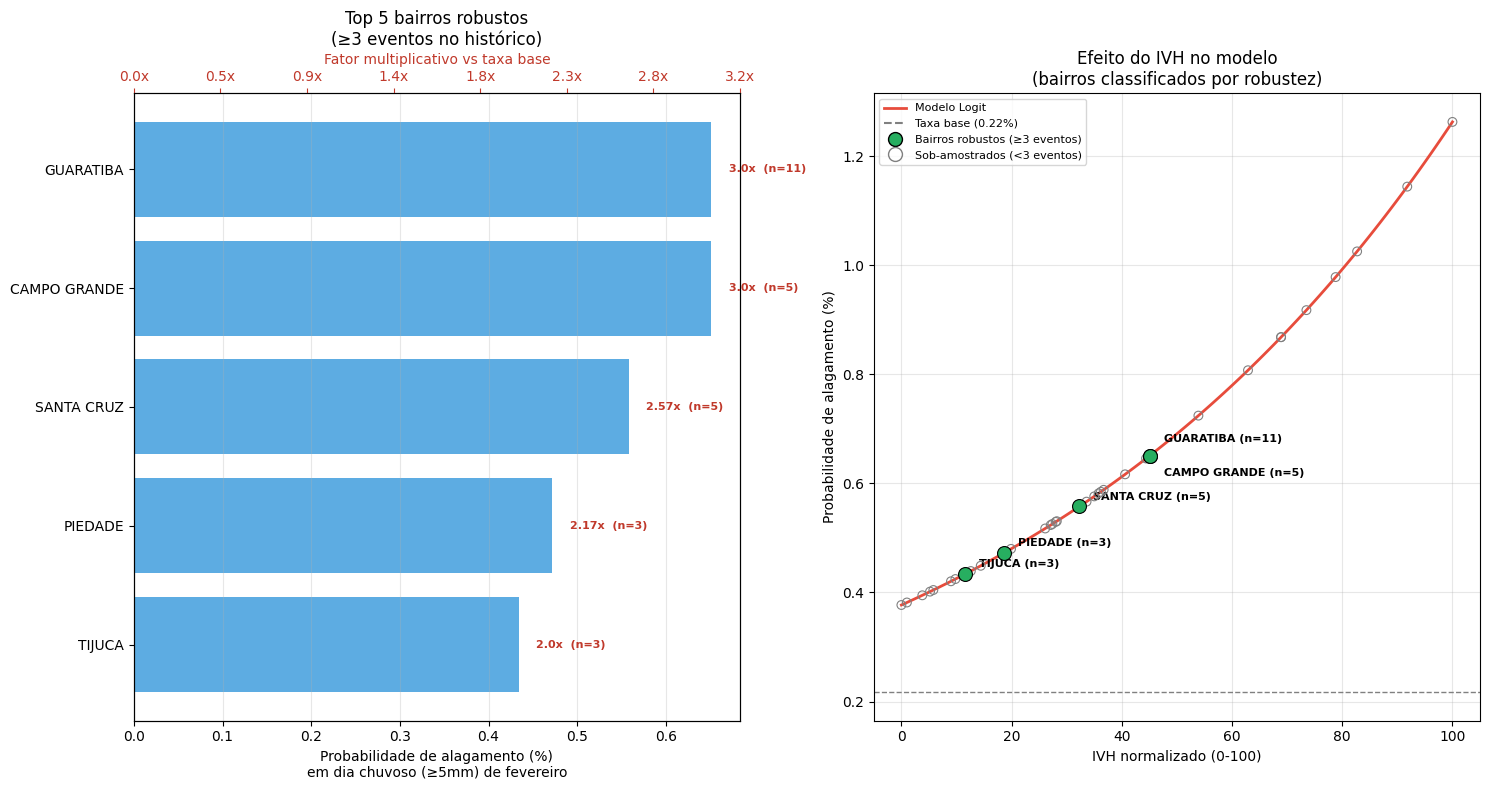


Taxa base do dataset: 0.217%

Top 10 bairros ROBUSTOS (≥3 eventos):
      bairro  ivh_normalizado  total_eventos  prob_alagamento_pct  fator_mult_baseline
   GUARATIBA             45.1             11                0.651                 3.00
CAMPO GRANDE             45.1              5                0.651                 3.00
  SANTA CRUZ             32.3              5                0.558                 2.57
     PIEDADE             18.6              3                0.472                 2.17
      TIJUCA             11.6              3                0.434                 2.00

Bairros SOB-AMOSTRADOS (1-2 eventos):
                   bairro  ivh_normalizado  total_eventos  prob_alagamento_pct  fator_mult_baseline
      SENADOR VASCONCELOS            100.0              1                1.263                 5.81
            BENTO RIBEIRO             91.8              1                1.145                 5.26
        ILHA DE GUARATIBA             82.7              1             

In [16]:
# Construir cenário típico pra cada bairro
ivh_completo = pd.read_parquet("../data/processed/indice_vulnerabilidade_hidrica.parquet")
ivh_completo = ivh_completo[["bairro", "ivh_normalizado", "total_eventos"]].copy()
ivh_completo["bairro"] = ivh_completo["bairro"].str.strip().str.upper()
ivh_completo = ivh_completo.sort_values("ivh_normalizado", ascending=False)

def construir_X_cenario(ivh_valor, mes_pico=2, colunas_modelo=X_treino.columns):
    X_row = pd.DataFrame(0, index=[0], columns=colunas_modelo)
    X_row["const"] = 1
    X_row["ivh_normalizado"] = ivh_valor
    if f"mes_{mes_pico}" in colunas_modelo:
        X_row[f"mes_{mes_pico}"] = 1
    return X_row.astype(float)

probs = []
for _, row in ivh_completo.iterrows():
    X_cenario = construir_X_cenario(row["ivh_normalizado"])
    prob = resultado.predict(X_cenario)[0]
    probs.append(prob)

ivh_completo["prob_alagamento_fev"] = probs
ivh_completo["prob_alagamento_pct"] = (ivh_completo["prob_alagamento_fev"] * 100).round(3)
taxa_base = y_treino.mean()
ivh_completo["fator_mult_baseline"] = (ivh_completo["prob_alagamento_fev"] / taxa_base).round(2)

# Separar em dois grupos: robustos (>= 3 eventos) e sob-amostrados (< 3)
THRESHOLD_ROBUSTO = 3
ivh_robustos = ivh_completo[ivh_completo["total_eventos"] >= THRESHOLD_ROBUSTO].copy()
ivh_sub_amostrados = ivh_completo[ivh_completo["total_eventos"] < THRESHOLD_ROBUSTO].copy()

print(f"Bairros robustos (≥{THRESHOLD_ROBUSTO} eventos): {len(ivh_robustos)}")
print(f"Bairros sob-amostrados (<{THRESHOLD_ROBUSTO} eventos): {len(ivh_sub_amostrados)}")

# Top 15 dos robustos pra visualização
top_robustos = ivh_robustos.head(15)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# (a) Ranking dos bairros robustos com fator multiplicativo
ax_prob = axes[0]
bars = ax_prob.barh(top_robustos["bairro"], top_robustos["prob_alagamento_pct"], color="#3498db", alpha=0.8)
ax_prob.set_xlabel("Probabilidade de alagamento (%)\nem dia chuvoso (≥5mm) de fevereiro")
ax_prob.set_title(f"Top {len(top_robustos)} bairros robustos\n(≥{THRESHOLD_ROBUSTO} eventos no histórico)")
ax_prob.invert_yaxis()
ax_prob.grid(alpha=0.3, axis="x")

# Eixo secundário: fator multiplicativo
ax_fator = ax_prob.twiny()
ax_fator.set_xlim(ax_prob.get_xlim())
xticks_prob = ax_prob.get_xticks()
ax_fator.set_xticks(xticks_prob)
ax_fator.set_xticklabels([f"{(x / 100) / taxa_base:.1f}x" for x in xticks_prob])
ax_fator.set_xlabel("Fator multiplicativo vs taxa base", color="#c0392b")
ax_fator.tick_params(axis="x", colors="#c0392b")

# Anotar número de eventos e fator multiplicativo
for bar, fator, n_eventos in zip(bars, top_robustos["fator_mult_baseline"], top_robustos["total_eventos"]):
    largura = bar.get_width()
    ax_prob.text(
        largura + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{fator}x  (n={n_eventos})",
        va="center",
        fontsize=8,
        color="#c0392b",
        fontweight="bold",
    )

# (b) Curva do modelo com bairros marcados por robustez
ivh_range = np.linspace(0, 100, 100)
probs_curva = []
for ivh_val in ivh_range:
    X_curva = construir_X_cenario(ivh_val)
    probs_curva.append(resultado.predict(X_curva)[0])

axes[1].plot(ivh_range, np.array(probs_curva) * 100, color="#e74c3c", linewidth=2, label="Modelo Logit")
axes[1].axhline(taxa_base * 100, color="gray", linestyle="--", linewidth=1, label=f"Taxa base ({taxa_base*100:.2f}%)")
axes[1].set_xlabel("IVH normalizado (0-100)")
axes[1].set_ylabel("Probabilidade de alagamento (%)")
axes[1].set_title("Efeito do IVH no modelo\n(bairros classificados por robustez)")
axes[1].grid(alpha=0.3)

# Bairros sob-amostrados primeiro (camada de fundo)
for _, row in ivh_sub_amostrados.iterrows():
    axes[1].scatter(row["ivh_normalizado"], row["prob_alagamento_fev"] * 100,
                    facecolors="none", edgecolors="gray", s=40, zorder=4, linewidth=0.8)

# Bairros robustos: pontos verdes por cima, com offsets manuais pra evitar sobreposição
offsets_anotacao = {
    "GUARATIBA": (10, 10),
    "CAMPO GRANDE": (10, -15),  # offset diferente pra não sobrepor com Guaratiba
    "SANTA CRUZ": (10, 5),
    "PIEDADE": (10, 5),
    "TIJUCA": (10, 5),
}

for _, row in ivh_robustos.iterrows():
    axes[1].scatter(row["ivh_normalizado"], row["prob_alagamento_fev"] * 100,
                    color="#27ae60", s=100, zorder=6, edgecolor="black", linewidth=0.8)
    offset = offsets_anotacao.get(row["bairro"], (5, 5))
    axes[1].annotate(
        f"{row['bairro']} (n={int(row['total_eventos'])})",
        (row["ivh_normalizado"], row["prob_alagamento_fev"] * 100),
        fontsize=8,
        xytext=offset,
        textcoords="offset points",
        fontweight="bold",
    )

# Legenda customizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#e74c3c", lw=2, label="Modelo Logit"),
    Line2D([0], [0], color="gray", linestyle="--", label=f"Taxa base ({taxa_base*100:.2f}%)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#27ae60", markersize=10,
           markeredgecolor="black", label=f"Bairros robustos (≥{THRESHOLD_ROBUSTO} eventos)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markersize=10,
           markeredgecolor="gray", label=f"Sob-amostrados (<{THRESHOLD_ROBUSTO} eventos)"),
]
axes[1].legend(handles=legend_elements, loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("../figuras/logit_probabilidade_bairros.png", dpi=150, bbox_inches="tight")
plt.show()

# Salvar tabela completa
ivh_completo["robusto"] = ivh_completo["total_eventos"] >= THRESHOLD_ROBUSTO
ivh_completo.to_csv("../data/processed/probabilidade_alagamento_por_bairro.csv", index=False)

print(f"\nTaxa base do dataset: {taxa_base*100:.3f}%")
print(f"\nTop 10 bairros ROBUSTOS (≥{THRESHOLD_ROBUSTO} eventos):")
print(ivh_robustos[["bairro", "ivh_normalizado", "total_eventos", "prob_alagamento_pct", "fator_mult_baseline"]].head(10).to_string(index=False))
print(f"\nBairros SOB-AMOSTRADOS (1-2 eventos):")
print(ivh_sub_amostrados[["bairro", "ivh_normalizado", "total_eventos", "prob_alagamento_pct", "fator_mult_baseline"]].to_string(index=False))

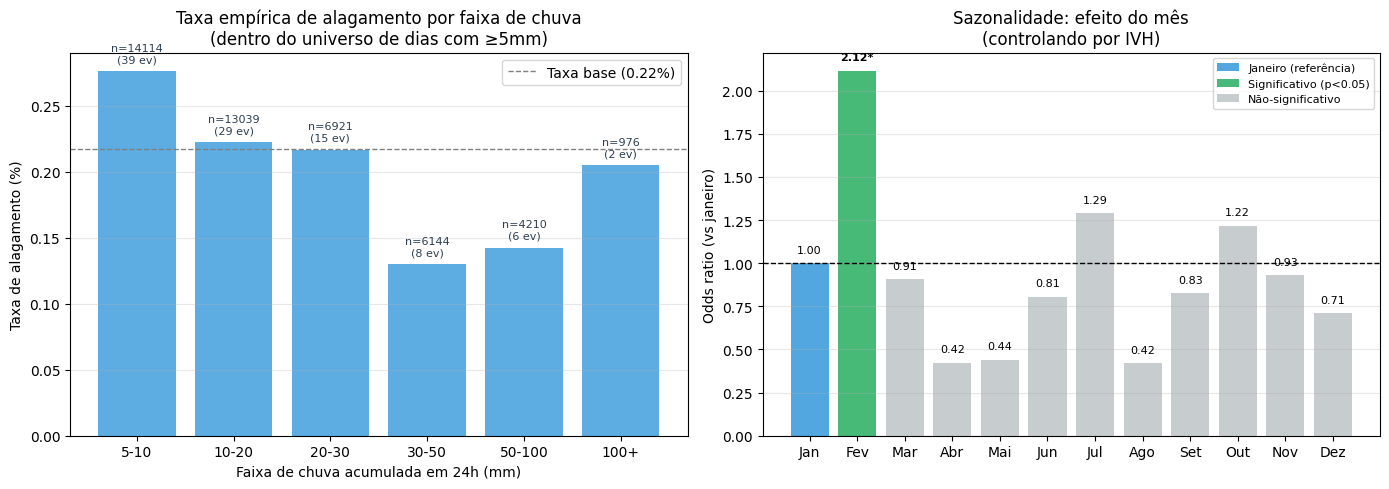

Resumo: taxa de alagamento por faixa de chuva
faixa_chuva  n_dias  n_eventos  taxa_eventos_pct
       5-10   14114         39          0.276321
      10-20   13039         29          0.222410
      20-30    6921         15          0.216732
      30-50    6144          8          0.130208
     50-100    4210          6          0.142518
       100+     976          2          0.204918

Fevereiro: odds ratio = 2.12x vs janeiro (significativo)


In [17]:
# Visualização: faixas de chuva (descritivo) + sazonalidade (modelo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Taxa empírica de alagamento por faixa de chuva — explica por que removemos chuva do modelo
treino_completo = treino.copy()
treino_completo["faixa_chuva"] = pd.cut(
    treino_completo["chuva_24h"],
    bins=[5, 10, 20, 30, 50, 100, 500],
    labels=["5-10", "10-20", "20-30", "30-50", "50-100", "100+"]
)

resumo_faixas = treino_completo.groupby("faixa_chuva", observed=True).agg(
    n_dias=("evento_ocorreu", "count"),
    n_eventos=("evento_ocorreu", "sum"),
    taxa_eventos=("evento_ocorreu", "mean"),
).reset_index()
resumo_faixas["taxa_eventos_pct"] = resumo_faixas["taxa_eventos"] * 100

bars = axes[0].bar(
    resumo_faixas["faixa_chuva"].astype(str),
    resumo_faixas["taxa_eventos_pct"],
    color="#3498db",
    alpha=0.8,
)
axes[0].axhline(taxa_base * 100, color="gray", linestyle="--", linewidth=1,
                label=f"Taxa base ({taxa_base*100:.2f}%)")
axes[0].set_xlabel("Faixa de chuva acumulada em 24h (mm)")
axes[0].set_ylabel("Taxa de alagamento (%)")
axes[0].set_title("Taxa empírica de alagamento por faixa de chuva\n(dentro do universo de dias com ≥5mm)")
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend()

# Anotar n de dias e n de eventos em cada barra
for bar, n_dias, n_ev in zip(bars, resumo_faixas["n_dias"], resumo_faixas["n_eventos"]):
    altura = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.005,
        f"n={n_dias}\n({n_ev} ev)",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#2c3e50",
    )

# (b) Sazonalidade: fator multiplicativo (odds ratio) por mês
nomes_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Construir tabela completa: janeiro = 1.0 (referência), demais = exp(coef)
coefs_meses_dict = {}
for mes_num in range(2, 13):
    feature_name = f"mes_{mes_num}"
    if feature_name in resultado.params.index:
        coefs_meses_dict[mes_num] = {
            "odds_ratio": np.exp(resultado.params[feature_name]),
            "p_value": resultado.pvalues[feature_name],
            "ci_lower": np.exp(resultado.conf_int().loc[feature_name, 0]),
            "ci_upper": np.exp(resultado.conf_int().loc[feature_name, 1]),
        }

meses_plot = pd.DataFrame({
    "mes_num": range(1, 13),
    "nome": nomes_meses,
})
meses_plot["odds_ratio"] = meses_plot["mes_num"].apply(
    lambda m: 1.0 if m == 1 else coefs_meses_dict.get(m, {}).get("odds_ratio", 1.0)
)
meses_plot["p_value"] = meses_plot["mes_num"].apply(
    lambda m: np.nan if m == 1 else coefs_meses_dict.get(m, {}).get("p_value", np.nan)
)
meses_plot["significativo"] = meses_plot["p_value"] < 0.05

# Cor verde pra meses significativos, cinza pros não-significativos, azul pra referência
cores_meses = []
for _, row in meses_plot.iterrows():
    if row["mes_num"] == 1:
        cores_meses.append("#3498db")  # janeiro = referência
    elif row["significativo"]:
        cores_meses.append("#27ae60")  # significativo
    else:
        cores_meses.append("#bdc3c7")  # não-significativo

bars_meses = axes[1].bar(meses_plot["nome"], meses_plot["odds_ratio"], color=cores_meses, alpha=0.85)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1, label="Referência (janeiro = 1.0)")
axes[1].set_ylabel("Odds ratio (vs janeiro)")
axes[1].set_title("Sazonalidade: efeito do mês\n(controlando por IVH)")
axes[1].grid(alpha=0.3, axis="y")

# Anotar odds ratio + asterisco pra significativos
for bar, odds, sig, mes_num in zip(bars_meses, meses_plot["odds_ratio"], meses_plot["significativo"], meses_plot["mes_num"]):
    altura = bar.get_height()
    label = f"{odds:.2f}"
    if sig:
        label += "*"
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.05,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold" if sig else "normal",
    )

# Legenda customizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3498db", alpha=0.85, label="Janeiro (referência)"),
    Patch(facecolor="#27ae60", alpha=0.85, label="Significativo (p<0.05)"),
    Patch(facecolor="#bdc3c7", alpha=0.85, label="Não-significativo"),
]
axes[1].legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("../figuras/logit_chuva_sazonalidade.png", dpi=150, bbox_inches="tight")
plt.show()

# Print de suporte pro relatório
print("Resumo: taxa de alagamento por faixa de chuva")
print(resumo_faixas[["faixa_chuva", "n_dias", "n_eventos", "taxa_eventos_pct"]].to_string(index=False))
print(f"\nFevereiro: odds ratio = {meses_plot[meses_plot['mes_num']==2]['odds_ratio'].iloc[0]:.2f}x vs janeiro (significativo)")